In [1]:
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import sys; sys.path.append('../')
import torch
from functools import singledispatch
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import normalize
from asterism.models.lda import GibbsLDA, GibbsSLDA, PyroLDA
from asterism.models.ncp import split, NCP
from asterism.models.ntm import ATLAS, NTM, RSB
from asterism.models.vae import VQAE
from asterism.utils.data import make_dataset
from asterism.utils.plots import show_comparison, show_dataset

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def remove_lonely(X, locs, y=None, k=12, cutoff=128.):
    adj = torch.cdist(locs, locs).sort(-1).values
    mask = adj[:, :k].mean(-1) < cutoff
    X, locs = X[mask], locs[mask]

    if y is not None:
        y = y[mask]

        return X, locs, y
    return X, locs

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


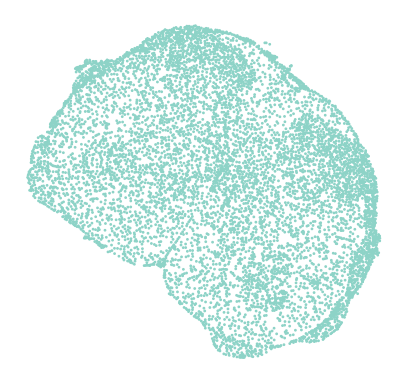

In [3]:
datasets = ['s13t02g93am06', 's13t12g93am06', 's13t06g93am04', 's13b02b6jlm06', 's13b12b6jlm06', 's13b06b6jlm04']
adata = mu.read(f'data/miil/{datasets[0]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data0 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data0, locs0 = remove_lonely(data0[:, 3:], data0[:, :3], k=12, cutoff=128.)
x_mask, y_mask = locs0[:, 1] < 7000, locs0[:, 2] < 6000
data0, locs0 = data0[x_mask*y_mask], locs0[x_mask*y_mask]
data0 = (data0 - data0.mean(0)[None])/data0.std(0)[None]
show_dataset(locs0, size=1)

/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/cwf25/Documents/Projects/asterism/.env/lib/python3.14/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


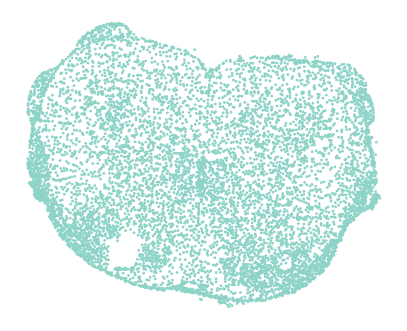

In [4]:
adata = mu.read(f'data/miil/{datasets[1]}.h5mu')
common_obs = adata['morphological'].obs_names.intersection(adata['protein'].obs_names).intersection(adata['imagenet'].obs_names)
morphological_data = adata['morphological'][common_obs]
img = torch.zeros((len(morphological_data), 1), dtype=torch.float32)
x, y = torch.tensor(morphological_data.obsm['spatial'].T, dtype=torch.float32)
protein_data = torch.tensor(adata['protein'][common_obs].X, dtype=torch.float32)
imagenet_data = torch.tensor(adata['imagenet'][common_obs].X, dtype=torch.float32)
data1 = torch.hstack([img, x[:, None], y[:, None], protein_data, imagenet_data])
data1, locs1 = remove_lonely(data1[:, 3:], data1[:, :3], k=12, cutoff=128.)
x_mask, y_mask = locs1[:, 1] < 7000, locs1[:, 2] < 6000
data1, locs1 = data1[x_mask*y_mask], locs1[x_mask*y_mask]
data1 = (data1 - data1.mean(0)[None])/data1.std(0)[None]
show_dataset(locs1, size=1)

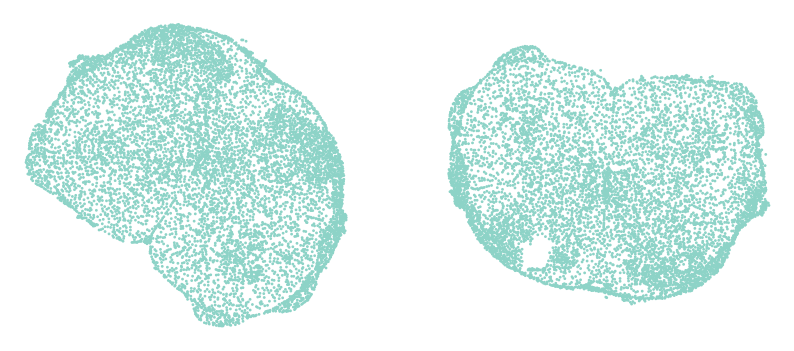

In [5]:
data = torch.cat([data0, data1])
locs1[:, 0] = 1
locs = torch.cat([locs0, locs1])
show_dataset(locs, size=1)

ATLAS: 100%|██████████| 200/200 [01:52<00:00,  1.77it/s]


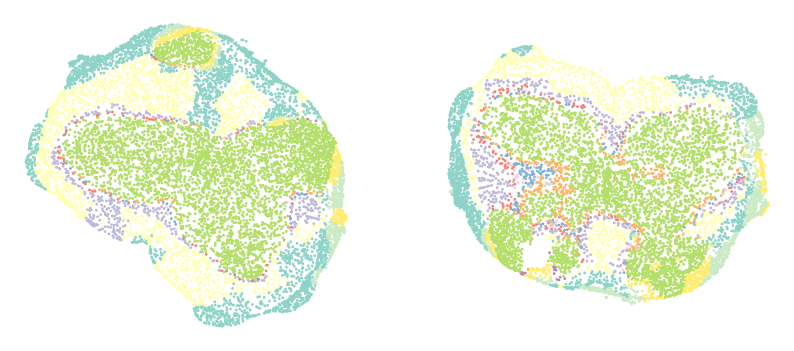

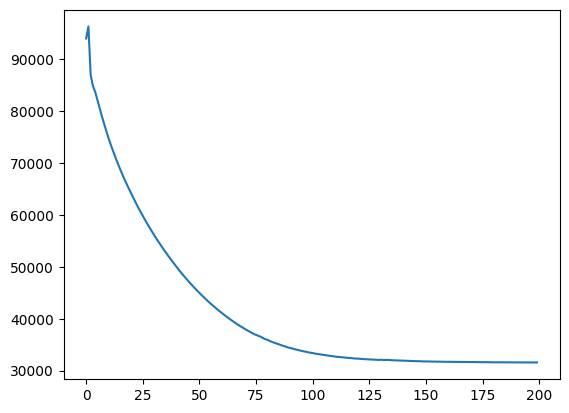

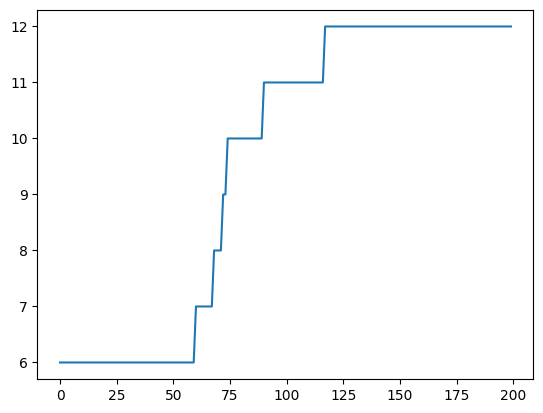

In [7]:
model = ATLAS(doc_size=128, topic_rate=.01)
topics = model.fit_predict(data, locs, n_steps=200)
show_dataset(locs, topics, size=1)
plt.plot(range(len(model.log_)), model.log_)
plt.show()
plt.plot(range(len(model.topic_log_)), model.topic_log_)
plt.show()

SLDA: 100%|██████████| 200/200 [05:47<00:00,  1.74s/it]


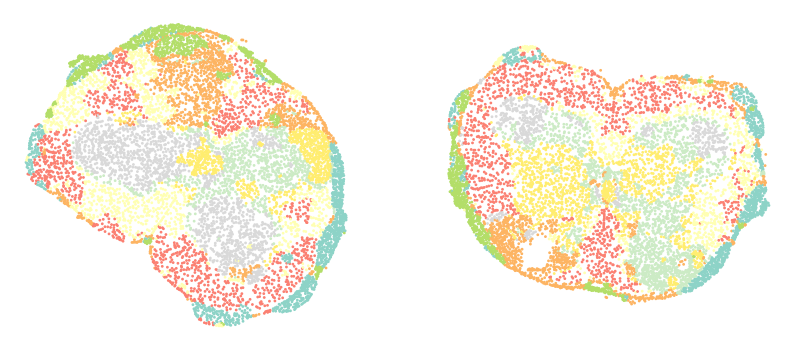

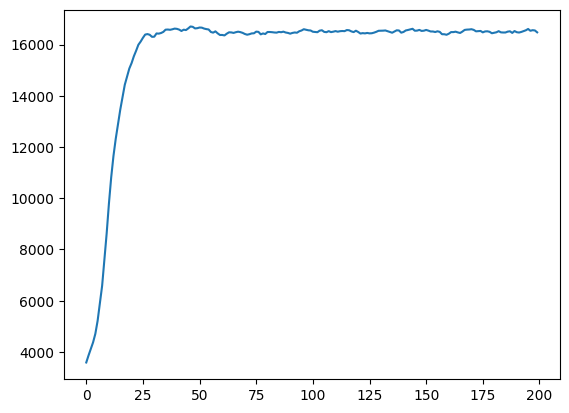

In [6]:
model = GibbsSLDA(8, data_size=8)
slda_topics = model.fit_predict(data.numpy(), locs.numpy())
show_dataset(locs, slda_topics, size=1)
plt.plot(range(len(model.log_)), model.log_)
plt.show()